# Phase 4 - Validation design and baselines
Goal: a validation score we can trust to predict the test score, and baselines every model must beat.

**Design rules**
1. *Forward in time.* Test (2026-02-16 to 2026-03-28) is after all training data, so every fold trains on the past and validates on the next 6 weeks.
2. *Rebuilt like the test.* Each fold's validation features are computed with history from before the cutoff only (frozen), exactly as test rows only see training history. Section 6 checks whether re-using the global feature table would overstate the score.
3. *Three seasons.* A = same season as the test one year earlier, B = monsoon-heavy autumn, C = the most recent 6 weeks.

**Metrics** - service: MAE and RMSE in minutes (plus R2, MAE on log). Lateness: log-loss and Brier (probability quality), AUC (ranking), ECE (calibration).

In [1]:
import sys, json; sys.path.append("../../tools/task1")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from task1_common import *
from task1_validation import FOLDS, make_fold, service_metrics, late_metrics
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
t = load_task1_tables()

## 1. Folds

In [2]:
train_lab = pd.read_pickle(INTERIM / 'train_labeled.pkl')
actuals = pd.read_pickle(INTERIM / 'train_actuals_diagnostic.pkl')
d = pd.to_datetime(train_lab.date)
print(pd.DataFrame([{'fold': n, 'valid_start': s, 'valid_end_excl': e,
                     'train_rows': (d < s).sum(), 'valid_rows': ((d >= s) & (d < e)).sum(),
                     'valid_late_rate': train_lab.late[(d >= s) & (d < e)].mean().round(4),
                     'valid_monsoon_share': train_lab.monsoon[(d >= s) & (d < e)].mean().round(3)} for n, s, e in FOLDS]).to_string(index=False))
print('\ntest window: 2026-02-16 -> 2026-03-28 | test monsoon share:', pd.read_pickle(INTERIM / 'test_features_base.pkl').monsoon.mean().round(3))

      fold valid_start valid_end_excl  train_rows  valid_rows  valid_late_rate  valid_monsoon_share
A_FebMar25  2025-02-17     2025-03-29       49055        4851           0.2136                0.683
B_SepOct25  2025-09-01     2025-10-12       71984        4996           0.1599                0.279
  C_recent  2026-01-03     2026-02-15       86721        5173           0.1311                0.000

test window: 2026-02-16 -> 2026-03-28 | test monsoon share: 0.665


## 2. Build and cache fold feature tables
About 30 s per fold. Cached in `data/processed/task1/folds/` for Phase 5.

In [3]:
FOLD_DIR = PROCESSED / 'folds'; FOLD_DIR.mkdir(parents=True, exist_ok=True)
folds = {}
for name, start, end in FOLDS:
    X_tr, X_va, meta = make_fold(train_lab, actuals, t, start, end)
    X_tr.to_pickle(FOLD_DIR / f'{name}_train.pkl'); X_va.to_pickle(FOLD_DIR / f'{name}_valid.pkl')
    folds[name] = (X_tr, X_va)
    print(f'{name}: train {X_tr.shape} | valid {X_va.shape}')
FEATURES, CATEGORICAL = meta['features'], meta['categorical']
with open(FOLD_DIR / 'folds_meta.json', 'w') as f:
    json.dump({'folds': FOLDS, **meta}, f, indent=1)
print('features:', len(FEATURES))

A_FebMar25: train (49055, 106) | valid (4851, 106)
B_SepOct25: train (71984, 106) | valid (4996, 106)
C_recent: train (86721, 106) | valid (5173, 106)
features: 101


## 3. Fold sanity checks
- No validation date inside its training set.
- Validation history is frozen: one value per outlet across the whole window (like test).

In [4]:
for name, (X_tr, X_va) in folds.items():
    no_overlap = X_tr.date.max() < X_va.date.min()
    frozen = X_va.groupby('outlet_id', observed=True).hist_outlet_log_svc_ratio.nunique().max() == 1
    print(f'{name}: train ends {X_tr.date.max().date()} < valid starts {X_va.date.min().date()}: {no_overlap} | history frozen per outlet: {frozen}')

A_FebMar25: train ends 2025-02-15 < valid starts 2025-02-17: True | history frozen per outlet: True
B_SepOct25: train ends 2025-08-30 < valid starts 2025-09-01: True | history frozen per outlet: True
C_recent: train ends 2026-01-02 < valid starts 2026-01-03: True | history frozen per outlet: True


## 4. Service-time baselines
| Baseline | Prediction |
|---|---|
| S0 brand median | median service of the brand in the fold's train |
| S1 dispatcher allowance | `service_allowance_min` (what the plan assumes today) |
| S2 outlet history | `exp_service_hist` = allowance x outlet's past service ratio |
| S3 quick GBM (untuned) | HistGradientBoosting on log target, all features, default-ish settings - a yardstick for Phase 5, not the final model |

In [5]:
def gbm_reg():
    return HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, categorical_features='from_dtype', random_state=SEED)

rows, svc_preds = [], {}
for name, (X_tr, X_va) in folds.items():
    y = X_va.service_min
    preds = {
        'S0 brand median': X_va.brand.map(X_tr.groupby('brand', observed=True).service_min.median()).astype(float),
        'S1 allowance': X_va.service_allowance_min.astype(float),
        'S2 outlet history': X_va.exp_service_hist,
        'S3 quick GBM': np.exp(gbm_reg().fit(X_tr[FEATURES], np.log(X_tr.service_min)).predict(X_va[FEATURES])),
    }
    svc_preds[name] = preds
    for m, p in preds.items():
        rows.append({'fold': name, 'model': m, **service_metrics(y, p)})
svc_res = pd.DataFrame(rows)
print(svc_res.pivot(index='model', columns='fold', values='MAE').assign(mean=lambda d: d.mean(axis=1)).round(3).to_string())
print()
print(svc_res.groupby('model')[['MAE', 'RMSE', 'R2', 'MAE_log']].mean().round(3).sort_values('MAE'))

fold               A_FebMar25  B_SepOct25  C_recent   mean
model                                                     
S0 brand median         6.514       6.361     7.106  6.660
S1 allowance            6.499       6.273     7.052  6.608
S2 outlet history       4.599       4.444     5.262  4.769
S3 quick GBM            3.631       3.463     3.770  3.622

                     MAE    RMSE     R2  MAE_log
model                                           
S3 quick GBM       3.622   5.738  0.807    0.207
S2 outlet history  4.769   7.624  0.663    0.270
S1 allowance       6.608  10.251  0.389    0.380
S0 brand median    6.660  10.673  0.337    0.379


## 5. Lateness baselines
| Baseline | Prediction |
|---|---|
| L0 base rate | fold-train late rate for every row |
| L1 brand x monsoon rate | late rate of the brand in that monsoon state |
| L2 logistic(planned slack) | 1-feature logistic regression on the dispatcher's own slack |
| L3 logistic(simulated slack) | 1-feature logistic regression on `sim_hist_slack` |
| L4 quick GBM (untuned) | HistGradientBoosting classifier, all features |

In [6]:
def gbm_clf():
    return HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, categorical_features='from_dtype', random_state=SEED)

def logit_1d(X_tr, X_va, col):
    m = LogisticRegression().fit(X_tr[[col]].fillna(0), X_tr.late)
    return m.predict_proba(X_va[[col]].fillna(0))[:, 1]

rows, late_preds = [], {}
for name, (X_tr, X_va) in folds.items():
    rate = X_tr.groupby(['brand', 'monsoon'], observed=True).late.mean()
    preds = {
        'L0 base rate': np.full(len(X_va), X_tr.late.mean()),
        'L1 brand x monsoon': X_va.set_index(['brand', 'monsoon']).index.map(rate).to_numpy(dtype=float),
        'L2 logit(plan slack)': logit_1d(X_tr, X_va, 'plan_slack'),
        'L3 logit(sim slack)': logit_1d(X_tr, X_va, 'sim_hist_slack'),
        'L4 quick GBM': gbm_clf().fit(X_tr[FEATURES], X_tr.late).predict_proba(X_va[FEATURES])[:, 1],
    }
    late_preds[name] = preds
    for m, p in preds.items():
        rows.append({'fold': name, 'model': m, **late_metrics(X_va.late, p)})
late_res = pd.DataFrame(rows)
print(late_res.pivot(index='model', columns='fold', values='logloss').assign(mean=lambda d: d.mean(axis=1)).round(4).to_string())
print()
print(late_res.groupby('model')[['logloss', 'brier', 'AUC', 'ECE', 'mean_pred', 'rate']].mean().round(4).sort_values('logloss'))

fold                  A_FebMar25  B_SepOct25  C_recent    mean
model                                                         
L0 base rate              0.5205      0.4446    0.4047  0.4566
L1 brand x monsoon        0.4995      0.4159    0.3860  0.4338
L2 logit(plan slack)      0.3539      0.3169    0.2845  0.3184
L3 logit(sim slack)       0.2109      0.1723    0.1817  0.1883
L4 quick GBM              0.1591      0.1287    0.1302  0.1393

                      logloss   brier     AUC     ECE  mean_pred    rate
model                                                                   
L4 quick GBM           0.1393  0.0436  0.9780  0.0108     0.1642  0.1682
L3 logit(sim slack)    0.1883  0.0543  0.9556  0.0195     0.1825  0.1682
L2 logit(plan slack)   0.3184  0.0948  0.8677  0.0493     0.1950  0.1682
L1 brand x monsoon     0.4338  0.1345  0.5898  0.0099     0.1732  0.1682
L0 base rate           0.4566  0.1410  0.5000  0.0441     0.1959  0.1682


## 6. Does the naive (global) feature table overstate the score?
Score the same quick GBMs on fold C, but with validation features taken from the global Phase 3 table (history keeps updating inside the window). Result: the scores match. The 21-day history lag built in Phase 3 already makes the global table test-like, which confirms that choice. We still use rebuilt folds because they reproduce test conditions exactly.

In [7]:
glob = pd.read_pickle(PROCESSED / 'task1_train_features.pkl')
name, start, end = FOLDS[2]
X_tr, X_va = folds[name]
naive_va = glob[(glob.date >= start) & (glob.date < end)]
naive_tr = glob[glob.date < start]
reg = gbm_reg().fit(naive_tr[FEATURES], np.log(naive_tr.service_min))
clf = gbm_clf().fit(naive_tr[FEATURES], naive_tr.late)
cmp = pd.DataFrame({
    'rebuilt (test-like)': {**{'svc_MAE': service_metrics(X_va.service_min, svc_preds[name]['S3 quick GBM'])['MAE']},
                            **{'late_logloss': late_metrics(X_va.late, late_preds[name]['L4 quick GBM'])['logloss']}},
    'naive (global features)': {'svc_MAE': service_metrics(naive_va.service_min, np.exp(reg.predict(naive_va[FEATURES])))['MAE'],
                                'late_logloss': late_metrics(naive_va.late, clf.predict_proba(naive_va[FEATURES])[:, 1])['logloss']}})
print(cmp.round(4))

              rebuilt (test-like)  naive (global features)
svc_MAE                    3.7698                   3.7695
late_logloss               0.1302                   0.1304


## 7. Calibration and error structure of the quick models

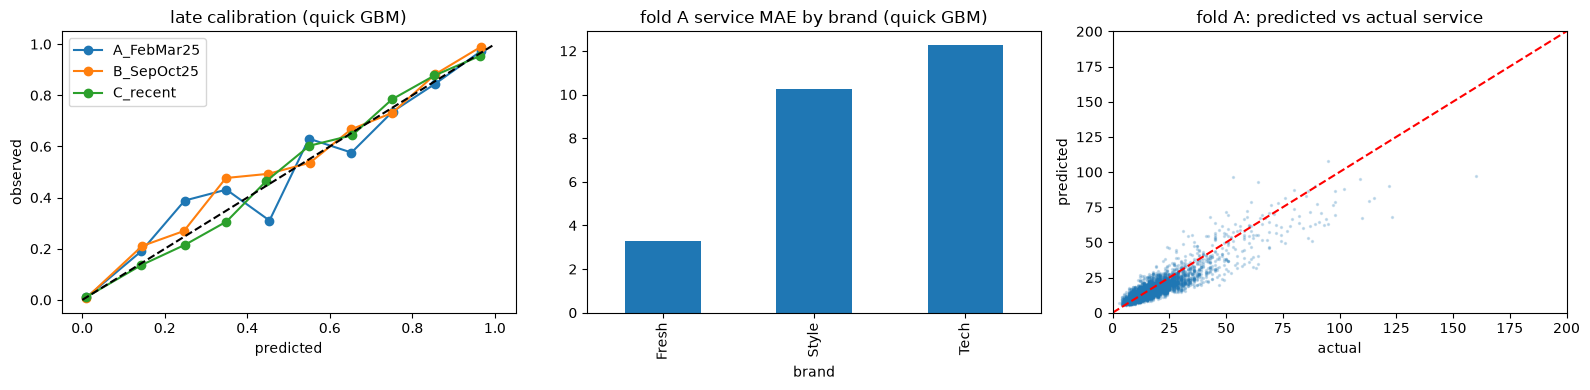

fold A MAE by brand: {'Fresh': 3.27, 'Style': 10.24, 'Tech': 12.28} | row share: {'Fresh': 0.953, 'Style': 0.031, 'Tech': 0.016}


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for name, (X_tr, X_va) in folds.items():
    p = late_preds[name]['L4 quick GBM']; b = np.minimum((p * 10).astype(int), 9)
    cal = pd.DataFrame({'p': p, 'y': X_va.late.values, 'b': b}).groupby('b').mean()
    ax[0].plot(cal.p, cal.y, marker='o', label=name)
ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].set_title('late calibration (quick GBM)'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('observed'); ax[0].legend()

X_va = folds['A_FebMar25'][1]; p = svc_preds['A_FebMar25']['S3 quick GBM']
err = pd.DataFrame({'brand': X_va.brand.astype(str), 'abs_err': np.abs(X_va.service_min - p), 'y': X_va.service_min})
err.groupby('brand').abs_err.mean().plot.bar(ax=ax[1]); ax[1].set_title('fold A service MAE by brand (quick GBM)')
ax[2].scatter(X_va.service_min, p, s=2, alpha=.2); ax[2].plot([0, 200], [0, 200], 'r--'); ax[2].set_xlim(0, 200); ax[2].set_ylim(0, 200)
ax[2].set_title('fold A: predicted vs actual service'); ax[2].set_xlabel('actual'); ax[2].set_ylabel('predicted')
plt.tight_layout(); plt.show()
print('fold A MAE by brand:', err.groupby('brand').abs_err.mean().round(2).to_dict(), '| row share:', err.brand.value_counts(normalize=True).round(3).to_dict())

## 8. Save baseline results

In [9]:
METRICS.mkdir(parents=True, exist_ok=True)
svc_res.to_csv(METRICS / 'task1_baselines_service.csv', index=False)
late_res.to_csv(METRICS / 'task1_baselines_late.csv', index=False)
print('saved to', METRICS)

saved to C:\Users\Asanka\Desktop\Hackbots_Datathon\reports\metrics


### Validation decisions
| # | Decision | Reason |
|---|---|---|
| 1 | Three 6-week forward folds (same-season A, monsoon B, recent C); select models on the **mean over folds**, watching fold A | One fold is noisy; the test is 6 weeks; A mirrors the test (68% monsoon, 21% late) while C has no monsoon |
| 2 | Rebuild fold features with frozen history | Reproduces test conditions exactly; section 6 shows the 21-day history lag already removes most optimism from the global table |
| 3 | Primary metrics: service MAE (minutes), late log-loss; also RMSE, Brier, AUC, ECE | MAE/log-loss are robust and probability-aware; the official metric is unknown, so we track all |
| 4 | Bar for Phase 5: beat S3 / L4 quick GBMs on every fold | Baselines S1/L2 show what the dispatcher has today |
